In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

In [67]:
df = pd.read_csv(r"D:\GitHub\SupervisedML_project\census.csv")
df.head()

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


## **Data Exploration**

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              45222 non-null  int64  
 1   workclass        45222 non-null  object 
 2   education_level  45222 non-null  object 
 3   education-num    45222 non-null  float64
 4   marital-status   45222 non-null  object 
 5   occupation       45222 non-null  object 
 6   relationship     45222 non-null  object 
 7   race             45222 non-null  object 
 8   sex              45222 non-null  object 
 9   capital-gain     45222 non-null  float64
 10  capital-loss     45222 non-null  float64
 11  hours-per-week   45222 non-null  float64
 12  native-country   45222 non-null  object 
 13  income           45222 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 4.8+ MB


In [69]:
num_records = df.shape[0]

num_income_above_50k = (df['income'] == '>50K').sum()

num_income_below_equal_50k = (df['income'] == '<=50K').sum()

percentage_above_50k = (num_income_above_50k / num_records) * 100

print("Number of records:", num_records)
print("Number of individuals with income >50K:", num_income_above_50k)
print("Number of individuals with income <=50K:", num_income_below_equal_50k)
print("Percentage of individuals with income >50K: {:.2f}%".format(percentage_above_50k))

Number of records: 45222
Number of individuals with income >50K: 11208
Number of individuals with income <=50K: 34014
Percentage of individuals with income >50K: 24.78%


## **Data Preprocessing**

In [70]:
X = df.drop("income", axis=1)
y = df["income"]

y = y.map({"<=50K":0, ">50K":1})

In [71]:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
Categorical columns: Index(['workclass', 'education_level', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')


## **Data Visualization**

##### **Outlier Detection**

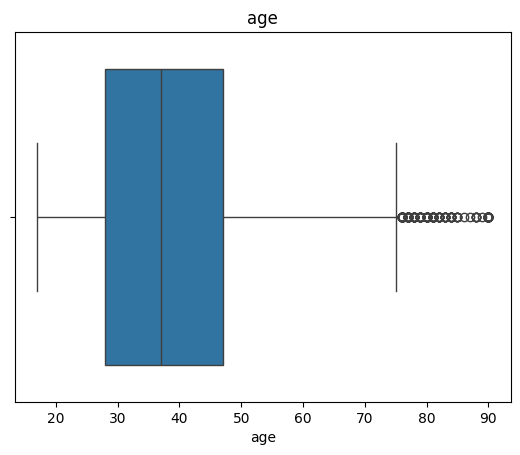

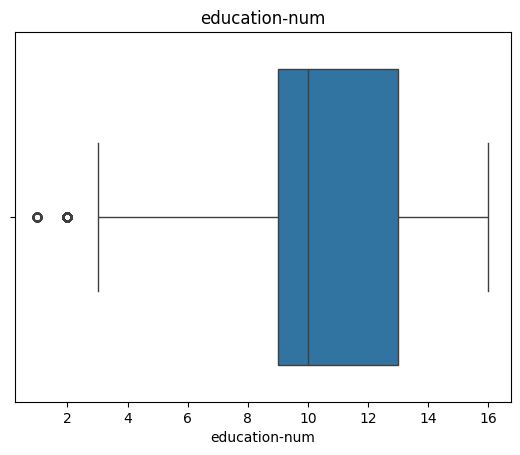

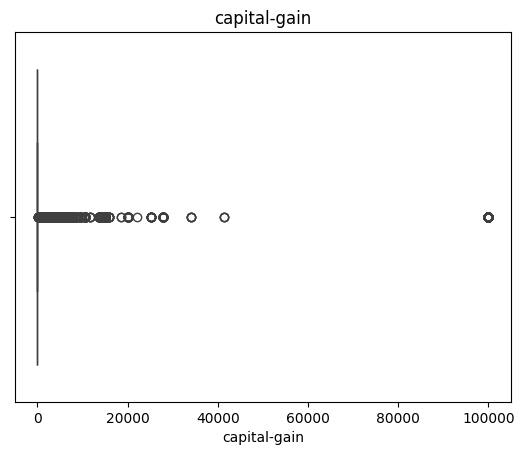

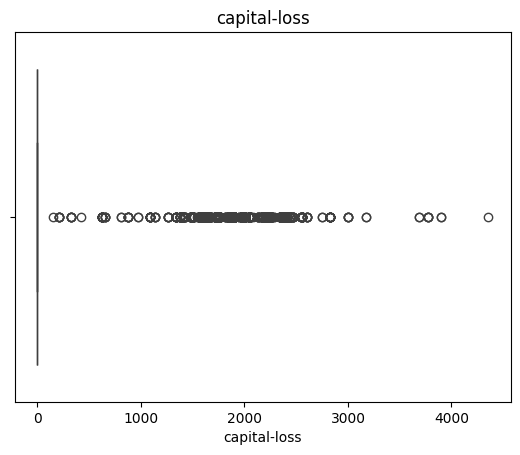

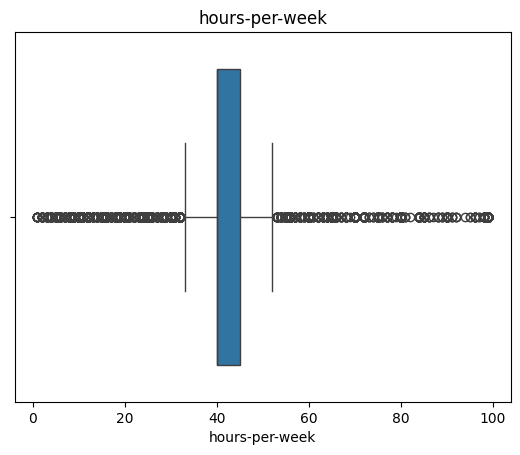

In [72]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

##### **Target Distribution**

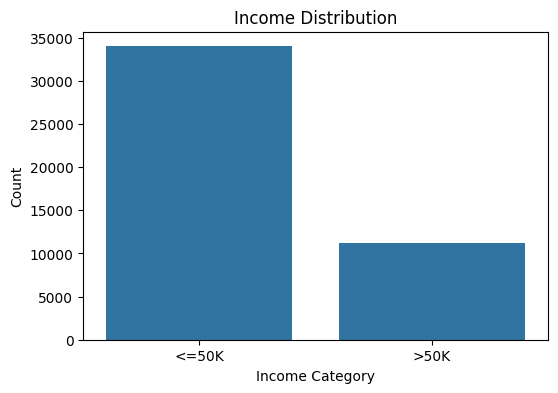

In [73]:
plt.figure(figsize=(6,4))
sns.countplot(x="income", data=df)

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")

plt.show()

##### **Numerical Feature Distributions**

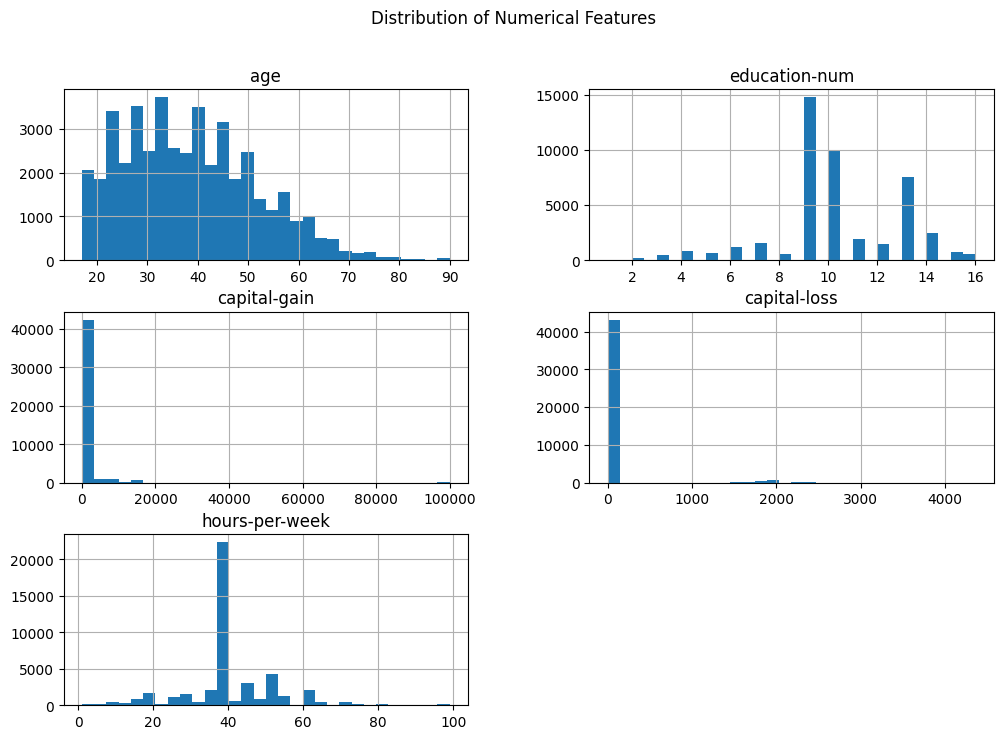

In [74]:
df[num_cols].hist(figsize=(12,8), bins=30)

plt.suptitle("Distribution of Numerical Features")
plt.show()

##### **Correlation Heatmap**

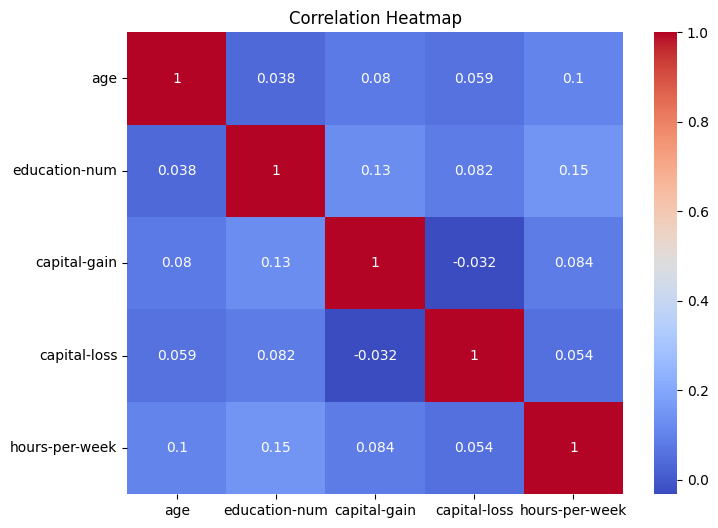

In [75]:
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap shows weak correlations between most numerical features. This indicates that no strong linear relationship exists among them, which reduces the risk of `multicollinearity` and allows models to learn independent feature contributions.

##### **Income vs Numerical Features**

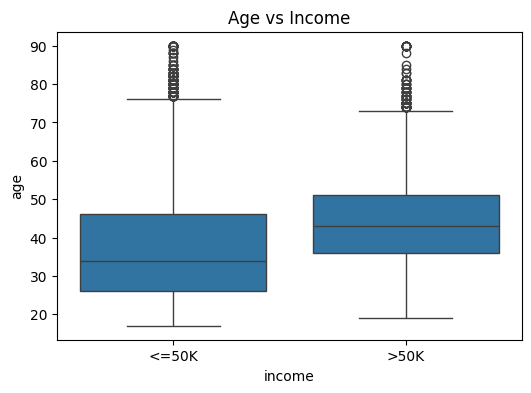

In [76]:
plt.figure(figsize=(6,4))
sns.boxplot(x="income", y="age", data=df)
plt.title("Age vs Income")

plt.show()

##### **Income vs Categorical Features**

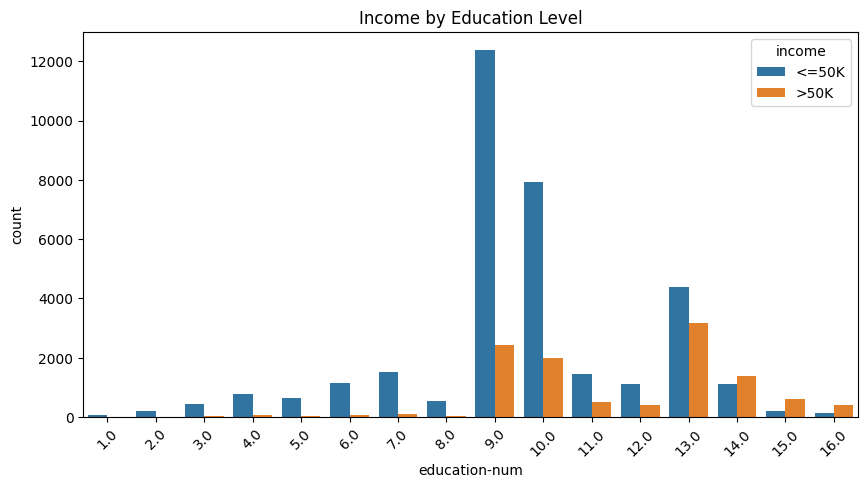

In [78]:
plt.figure(figsize=(10,5))
sns.countplot(x="education-num", hue="income", data=df)
plt.xticks(rotation=45)
plt.title("Income by Education Level")

plt.show()

## **Pipelines**

##### **Preprocessing for Logistic Regression**

In [ ]:
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor_lr = ColumnTransformer([
    ("num", RobustScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

##### **Logistic Regression Pipeline**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ("preprocessing", preprocessor_lr),
    ("model", LogisticRegression(max_iter=1000))
])

##### **Preprocessing for Tree Models (No Scaling)**

In [ ]:
preprocessor_tree = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")    # (remainder="passthrough") keeps numeric features unchanged

##### **Decision Tree Pipeline**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

pipe_dt = Pipeline([
    ("preprocessing", preprocessor_tree),
    ("model", DecisionTreeClassifier())
])

##### **Random Forest Pipeline**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("preprocessing", preprocessor_tree),
    ("model", RandomForestClassifier())
])